In [237]:
import pandas as pd
monthly_complete = pd.read_csv("monthly_data.csv")

In [238]:
import numpy as np
import matplotlib.pyplot as plt

city = "Delhi"
city_df = monthly_complete[monthly_complete["City"] == city]
city_df["Date"] = pd.to_datetime(city_df["Date"])

city_df.set_index("Date", inplace = True)

#Extract crime series
series = city_df["Crime_Count"]

series.head()

Date
2020-01-01     94
2020-02-01     77
2020-03-01    120
2020-04-01    107
2020-05-01    112
Name: Crime_Count, dtype: int64

In [239]:
"""
Altering the dataframe for using random forest model
"""

df_ml = city_df.copy()

#Creating lags
for lag in [1, 2, 3, 6, 12]:
    df_ml[f"lag_{lag}"] = df_ml["Crime_Count"].shift(lag)

df_ml["MA6"] = df_ml["Crime_Count"].rolling(6).mean()

df_ml = df_ml.dropna()
df_ml.head()

,City,Year of Occurrence,Month of Occurrence,Crime_Count,MA3,Delta,Trend_Slope,lag_1,lag_2,lag_3,lag_6,lag_12,MA6
Date,,,,,,,,,,,,,
2021-01-01,Delhi,2021,1,98,95.666667,0.0,-0.05267,98.0,91.0,107.0,105.0,94.0,98.166667
2021-02-01,Delhi,2021,2,95,97.000000,-3.0,-0.05267,98.0,98.0,91.0,96.0,77.0,98.000000
2021-03-01,Delhi,2021,3,101,98.000000,6.0,-0.05267,95.0,98.0,98.0,99.0,120.0,98.333333
2021-04-01,Delhi,2021,4,105,100.333333,4.0,-0.05267,101.0,95.0,98.0,107.0,107.0,98.000000
2021-05-01,Delhi,2021,5,102,102.666667,-3.0,-0.05267,105.0,101.0,95.0,91.0,112.0,99.833333


In [240]:
#Features (using only specific ones to avoid overfitting)
x = df_ml[["lag_1", "lag_2", "lag_3",
           "lag_6", "lag_12", "MA3", "MA6"]]
#Target
y = df_ml["Crime_Count"]


In [241]:
x_train = x[:"2023-12-01"]
x_test = x["2024-01-01":]

y_train = y[:"2023-12-01"]
y_test = y["2024-01-01":]

print("Train size:", len(x_train))
print("test size:", len(x_test))

Train size: 36
test size: 7


In [242]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators = 300,
    max_depth = 5,
    random_state=42
)

rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

MAE Random Forest: 4.862330492569983
RMSE Random Forest: 6.970945904755663


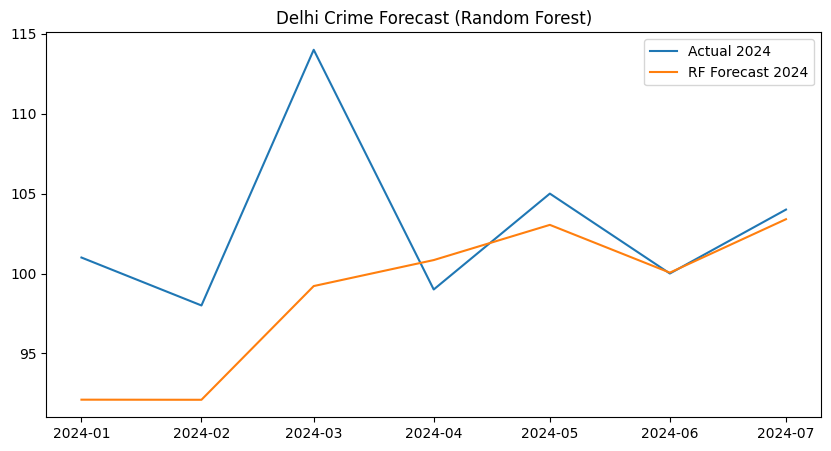

In [243]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

rf_pred = rf.predict(x_test)

mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))

print("MAE Random Forest:", mae_rf)
print("RMSE Random Forest:", rmse_rf)

plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual 2024")
plt.plot(y_test.index, rf_pred, label="RF Forecast 2024")
plt.legend()
plt.title("Delhi Crime Forecast (Random Forest)")
plt.show()

In [244]:
#Rebuilding the full feature set guarantees clean time-order logic before we slice it repeatedly.

df_ml = city_df.copy()

for lag in [1, 2, 3, 6, 12]:
    df_ml[f"lag_{lag}"] = df_ml["Crime_Count"].shift(lag)

df_ml["MA6"] = df_ml["Crime_Count"].rolling(6).mean()

df_ml = df_ml.dropna()
df_ml.head()

,City,Year of Occurrence,Month of Occurrence,Crime_Count,MA3,Delta,Trend_Slope,lag_1,lag_2,lag_3,lag_6,lag_12,MA6
Date,,,,,,,,,,,,,
2021-01-01,Delhi,2021,1,98,95.666667,0.0,-0.05267,98.0,91.0,107.0,105.0,94.0,98.166667
2021-02-01,Delhi,2021,2,95,97.000000,-3.0,-0.05267,98.0,98.0,91.0,96.0,77.0,98.000000
2021-03-01,Delhi,2021,3,101,98.000000,6.0,-0.05267,95.0,98.0,98.0,99.0,120.0,98.333333
2021-04-01,Delhi,2021,4,105,100.333333,4.0,-0.05267,101.0,95.0,98.0,107.0,107.0,98.000000
2021-05-01,Delhi,2021,5,102,102.666667,-3.0,-0.05267,105.0,101.0,95.0,91.0,112.0,99.833333


In [245]:
#Walking-forward forecast to ensure model robustness

predictions = []
actuals = []

test_dates = df_ml.loc["2024-01-01":].index

for current_date in test_dates:

    #Training data = everything before current_date
    train_data = df_ml.loc[:current_date - pd.DateOffset(months = 1)]

    x_train = train_data[[
        "lag_1", "lag_2", "lag_3",
        "lag_6", "lag_12", "MA3", "MA6"
    ]]

    y_train = train_data["Crime_Count"]

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        random_state=42
    )

    rf.fit(x_train, y_train)

    #Extracting test row (single month)
    x_test = df_ml.loc[current_date, [
        "lag_1", "lag_2", "lag_3",
        "lag_6", "lag_12", "MA3", "MA6"
    ]].values.reshape(1, -1)

    prediction = rf.predict(x_test)[0]

    predictions.append(prediction)
    actuals.append(df_ml.loc[current_date, "Crime_Count"])

d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not

MAE roll: 4.751483832181336
RMSE roll: 7.09238056824079


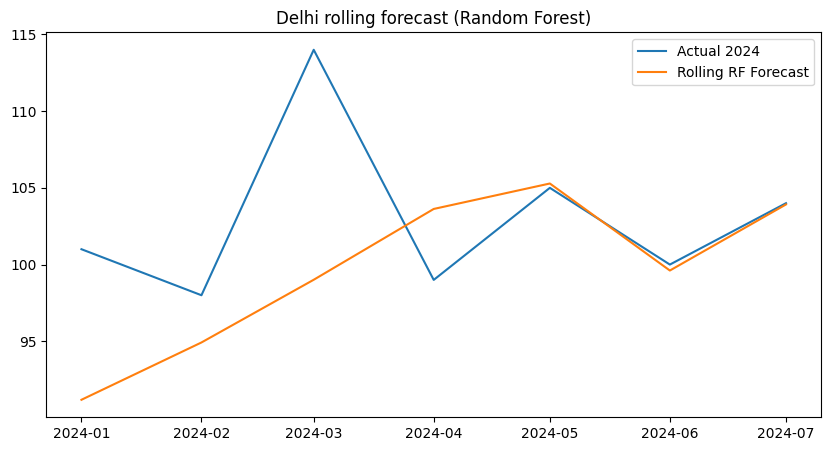

In [246]:
mae_roll = mean_absolute_error(actuals, predictions)
rmse_roll = np.sqrt(mean_squared_error(actuals, predictions))

print("MAE roll:", mae_roll)
print("RMSE roll:", rmse_roll)

plt.figure(figsize=(10, 5))
plt.plot(test_dates, actuals, label = "Actual 2024")
plt.plot(test_dates, predictions, label = "Rolling RF Forecast")
plt.legend()
plt.title("Delhi rolling forecast (Random Forest)")
plt.show()

In [251]:
city = "Pune"
city_df = monthly_complete[monthly_complete["City"] == city]
city_df["Date"] = pd.to_datetime(city_df["Date"])

city_df.set_index("Date", inplace = True)
print(city_df.head())

            City  Year of Occurrence  Month of Occurrence  Crime_Count   MA3  \
Date                                                                           
2020-01-01  Pune                2020                    1           45   NaN   
2020-02-01  Pune                2020                    2           44   NaN   
2020-03-01  Pune                2020                    3           46  45.0   
2020-04-01  Pune                2020                    4           48  46.0   
2020-05-01  Pune                2020                    5           38  44.0   

            Delta  Trend_Slope  
Date                            
2020-01-01    NaN     0.040476  
2020-02-01   -1.0     0.040476  
2020-03-01    2.0     0.040476  
2020-04-01    2.0     0.040476  
2020-05-01  -10.0     0.040476  


In [254]:
df_ml = city_df.copy()

for lag in [1, 2, 3, 6, 12]:
    df_ml[f"lag_{lag}"] = df_ml["Crime_Count"].shift(lag)

df_ml["MA6"] = df_ml["Crime_Count"].rolling(6).mean()

df_ml = df_ml.dropna()

In [255]:
#Walking-forward forecast to ensure model robustness

predictions = []
actuals = []

test_dates = df_ml.loc["2024-01-01":].index

for current_date in test_dates:

    #Training data = everything before current_date
    train_data = df_ml.loc[:current_date - pd.DateOffset(months = 1)]

    x_train = train_data[[
        "lag_1", "lag_2", "lag_3",
        "lag_6", "lag_12", "MA3", "MA6"
    ]]

    y_train = train_data["Crime_Count"]

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        random_state=42
    )

    rf.fit(x_train, y_train)

    #Extracting test row (single month)
    x_test = df_ml.loc[current_date, [
        "lag_1", "lag_2", "lag_3",
        "lag_6", "lag_12", "MA3", "MA6"
    ]].values.reshape(1, -1)

    prediction = rf.predict(x_test)[0]

    predictions.append(prediction)
    actuals.append(df_ml.loc[current_date, "Crime_Count"])

d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not

Pune Rolling MAE: 6.493766528381691
Pune Rolling RMSE: 7.362968334494681


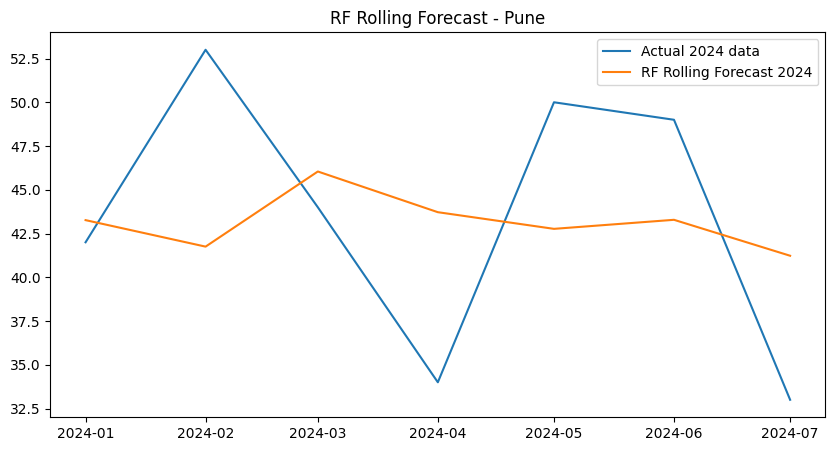

In [256]:
mae_roll = mean_absolute_error(actuals, predictions)
rmse_roll = np.sqrt(mean_squared_error(actuals, predictions))

print("Pune Rolling MAE:", mae_roll)
print("Pune Rolling RMSE:", rmse_roll)

plt.figure(figsize=(10, 5))
plt.plot(test_dates, actuals, label = "Actual 2024 data")
plt.plot(test_dates, predictions, label = "RF Rolling Forecast 2024")
plt.legend()
plt.title("RF Rolling Forecast - Pune")
plt.show()